# Libraries and functions importation

In [1]:
!pip install missingno
!pip install imblearn
!pip install xgboost
!pip install


ERROR: You must give at least one requirement to install (see "pip help install")


In [2]:
!pip install mlxtend

In [3]:
# Libraries and functions importation
import pandas as pd
import numpy as np
import itertools
import scipy as sp
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import missingno as msno
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as IMBPipeline

# trasformation
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# scores
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, roc_curve
from sklearn.metrics import precision_score, accuracy_score, recall_score
#from sklearn.metrics import plot_roc_curve
from sklearn.metrics import RocCurveDisplay

# classifier and feature selection
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from mlxtend.classifier import Adaline
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from scipy.stats import loguniform, beta, uniform

# Download the dataset
## Breast Cancer dataset from Kaggle - Corrupted version

The dataset provides data on breast cancer patients, including demographic, clinical, and treatment-related information. it is used for binary classification of patients into two cateogries: "Alive" and "Dead".

Here is a summary of the columns present in the data:

- Age: The age of the patient.                                                                                                

- Race: The race of the patient (some values are missing).                                                  

- Marital Status: The marital status of the patient (many values are missing).                                

- T Stage: Tumor stage (T1, T2, T3, etc.).                                                                                       

- N Stage: Node stage (N1, N2, N3, etc.).                                                                                         

- 6th Stage: Cancer stage according to the 6th edition staging system.                                                                                                                         

- Differentiate: The differentiation status of the tumor cells.                                   

- Grade: The grade of the cancer.                                                                                                   

- A Stage: The anatomic stage of the cancer.                                                                               

- Tumor Size: The size of the tumor in millimeters.                                                                    

- Estrogen Status: Estrogen receptor status (e.g., "Positive").                                            

- Progesterone Status: Progesterone receptor status (e.g., "Positive").                                       

- Regional Node Examined: Number of regional lymph nodes examined.                                

- Regional Node Positive: Number of positive regional lymph nodes.                                             

* Survival Months: Number of months the
patient survived after diagnosis or treatment.
Excluded from the feature set: it records what happened after diagnosis, so it is not available at the moment a prediction would need to be made. Using it as a predictor would leak the outcome into the model.           






- Status: The survival status of the patient (e.g., "Alive").

The following dataset contains missing values in some feature columns, since i have corrupted the original clean version taken from kaggle.


In [4]:
dataset = pd.read_csv('Breast_Cancer_Corrupted.csv')

# Show info
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4064 entries, 0 to 4063
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3984 non-null   float64
 1   Race                    202 non-null    object 
 2   Marital Status          805 non-null    object 
 3   T Stage                 4024 non-null   object 
 4   N Stage                 4024 non-null   object 
 5   6th Stage               3924 non-null   object 
 6   Differentiate           1208 non-null   object 
 7   Grade                   4024 non-null   object 
 8   A Stage                 4024 non-null   object 
 9   Tumor Size              4024 non-null   float64
 10  Estrogen Status         4024 non-null   object 
 11  Progesterone Status     4024 non-null   object 
 12  Regional Node Examined  4024 non-null   float64
 13  Reginol Node Positive   4024 non-null   float64
 14  Survival Months         3220 non-null   

        Count  Percentage
Status                   
Alive    3408      84.692
Dead      616      15.308


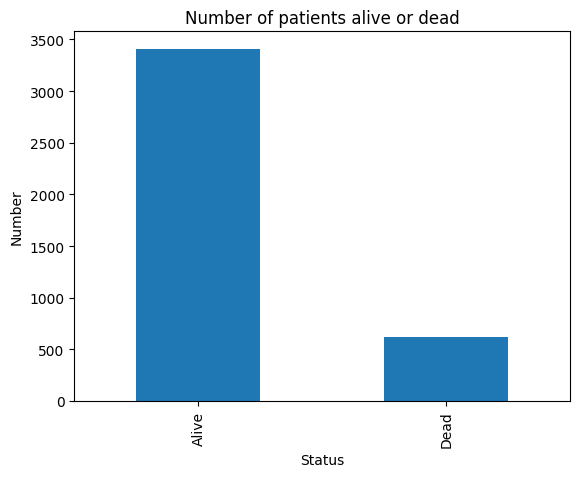

In [5]:
# I analyse if the dataset is balanced:

# calculating value_counts for the column 'Status'
status_counts = dataset['Status'].value_counts()

# calculating the perentage of values
status_percentages = dataset['Status'].value_counts(normalize=True) * 100

#combining the counting with the corresponding percentage value.
summary = pd.DataFrame({
    'Count': status_counts,
    'Percentage': status_percentages
})

# show the result
summary['Percentage'] = summary['Percentage'].round(3)  # round the percentage to three decimal digits
print(summary)

status_counts.plot(kind='bar', xlabel='Status', ylabel='Number', title='Number of patients alive or dead')
plt.show()

As it can be seen from this graph, the two classes are unbalanced, since there is a great majority (almost 85 %) of the class "Alive" over the class "Dead".

According to this, in my model I need to address the problem inserting synthetic data using the SMOTE (Synthetic Minority Over-sampling Technique) method.

# Pre-processing

In [6]:
#PROPORTION OF NULL VALUES IN EACH COLUMN
dataset.isnull().sum(axis=0)/dataset.shape[0]

,0
Age,0.019685
Race,0.950295
Marital Status,0.801919
T Stage,0.009843
N Stage,0.009843
6th Stage,0.034449
Differentiate,0.702756
Grade,0.009843
A Stage,0.009843
Tumor Size,0.009843


<Axes: >

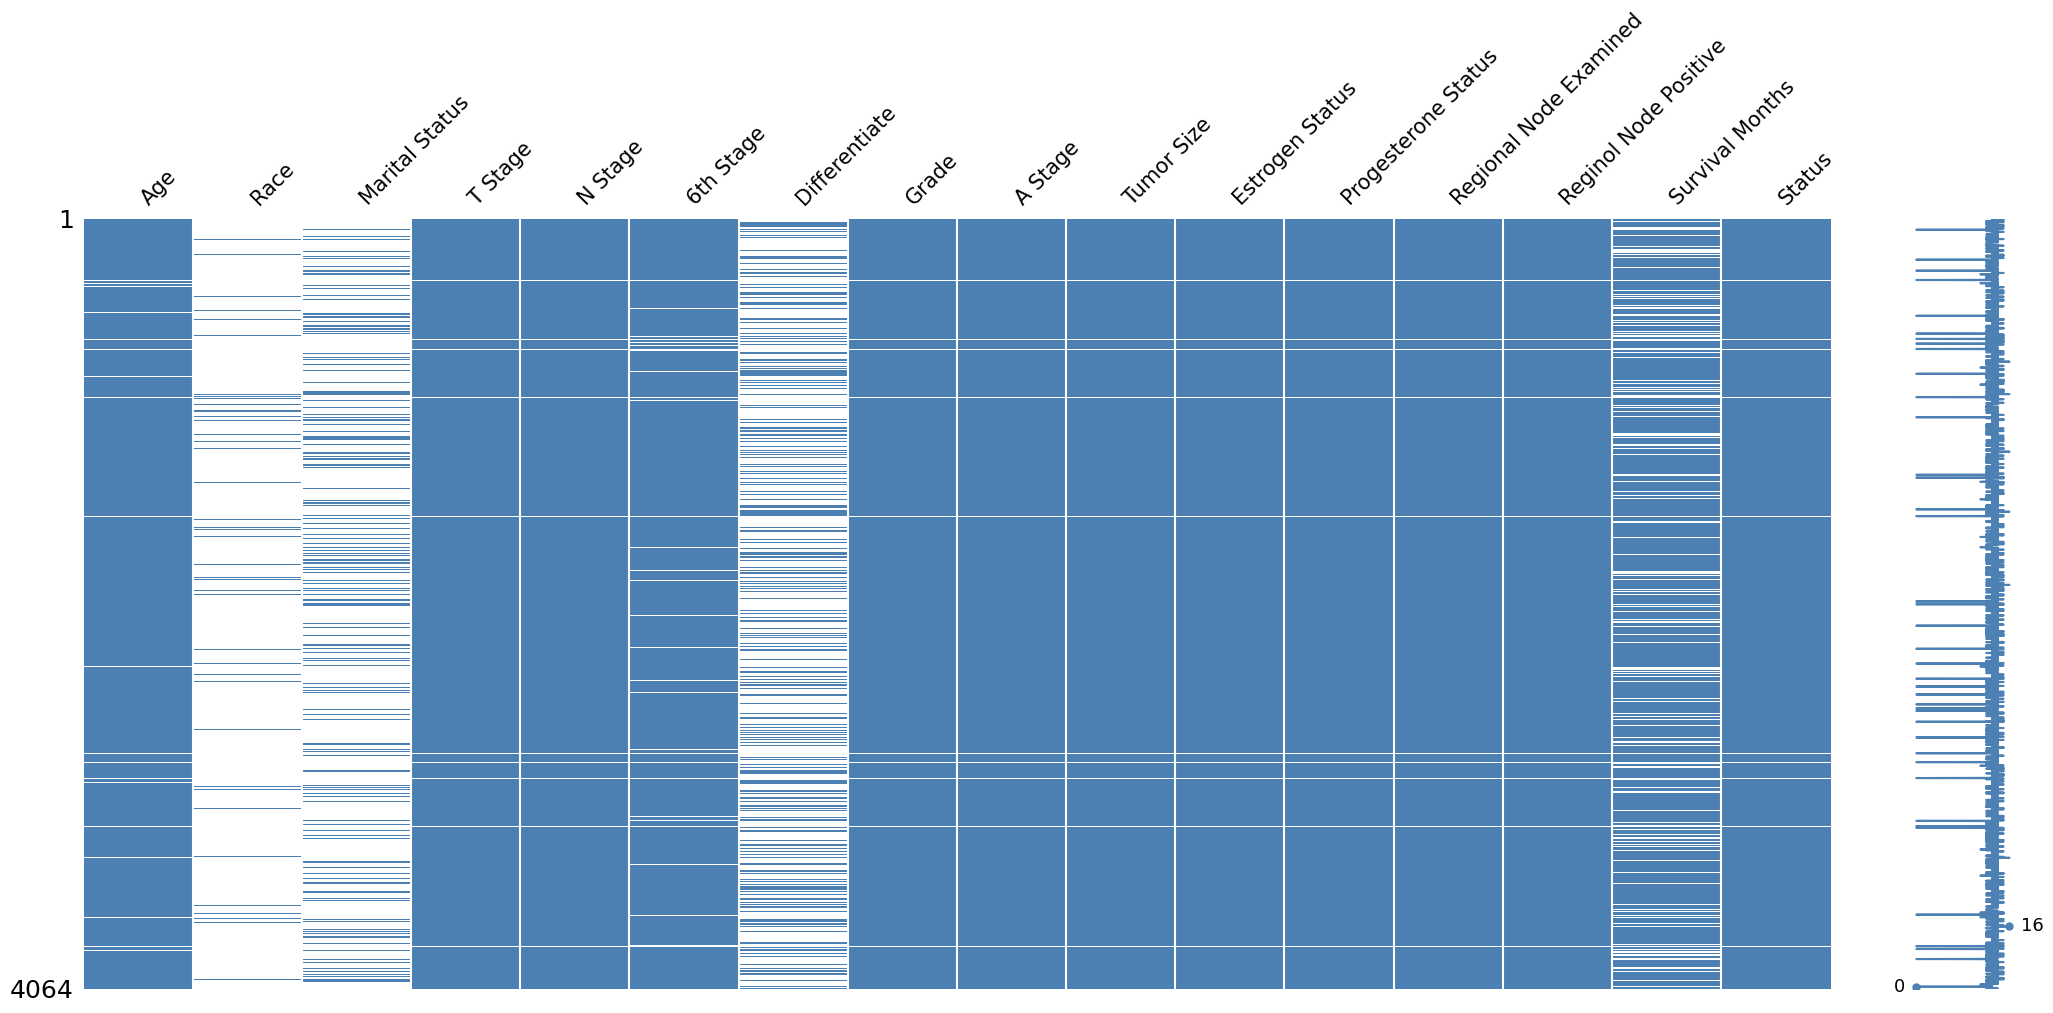

In [7]:
# Show missing values and rows using missingno
msno.matrix(dataset,color=(0.3, 0.5, 0.7), fontsize=15)

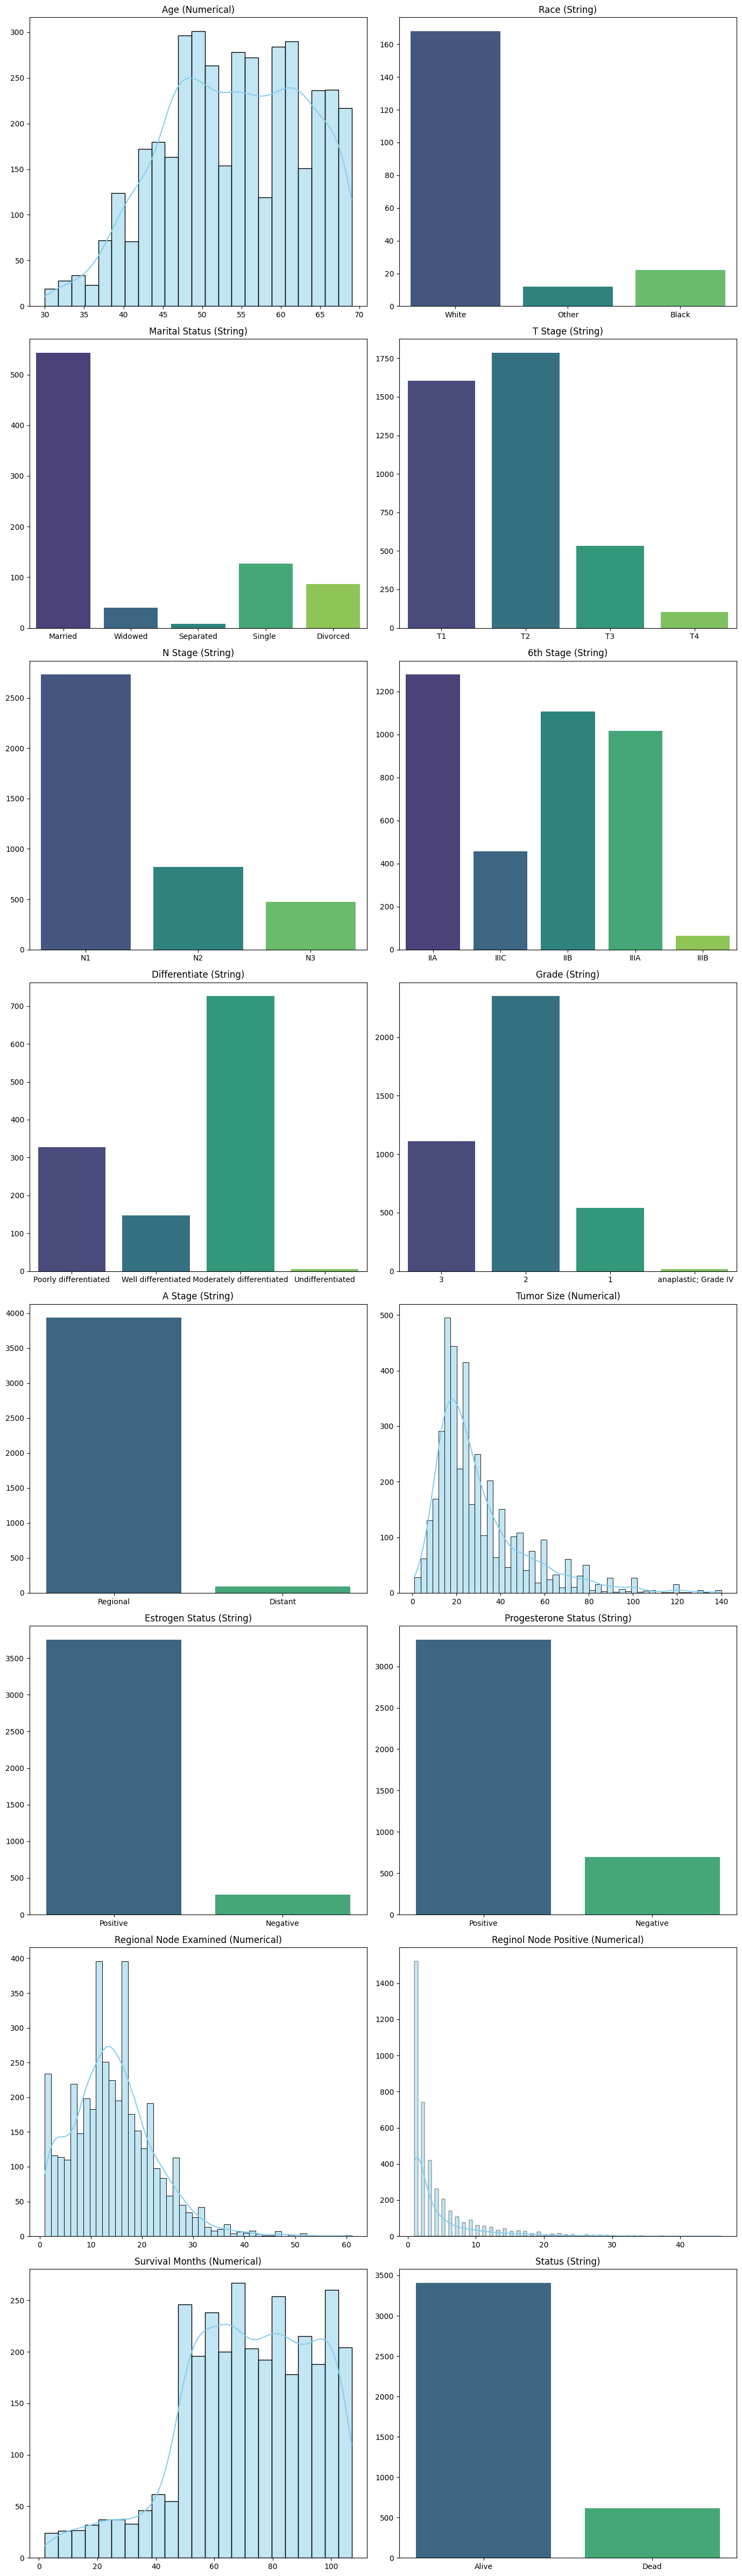

In [8]:
# selecting the number of columns and rows for layout
num_cols = len(dataset.columns)
num_rows = int(np.ceil(num_cols / 2))

# create a figure with columns and rows
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, 6 * num_rows), sharey=False)

# flatten the axes
axes = axes.flatten()

# plotting each column:
for i, col in enumerate(dataset.columns):
    ax = axes[i]
    if dataset[col].dtype == 'object':  # Categorical
        sns.countplot(data=dataset, x=col, ax=ax, palette='viridis')
        ax.set_title(f'{col} (String)')
    else:  # Numerical
        sns.histplot(dataset[col], ax=ax, kde=True, color='skyblue')
        ax.set_title(f'{col} (Numerical)')

    ax.set_xlabel('')
    ax.set_ylabel('')

# remove axes not used.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# regulate the layout to avoid sovrappositions
plt.tight_layout()
plt.show()

In [9]:
# Sostituire "Alive" con 1 e "Dead" con 0
dataset['Status'] = dataset['Status'].replace({'Alive': 1, 'Dead': 0})

# Drop useless columns and null rows full of null values
dataset.drop(['Race'], axis=1, inplace=True)
dataset.drop(['Marital Status'], axis=1, inplace=True)
dataset.drop(['Differentiate'], axis=1, inplace=True)
dataset.dropna(how='all',inplace=True)

<Axes: >

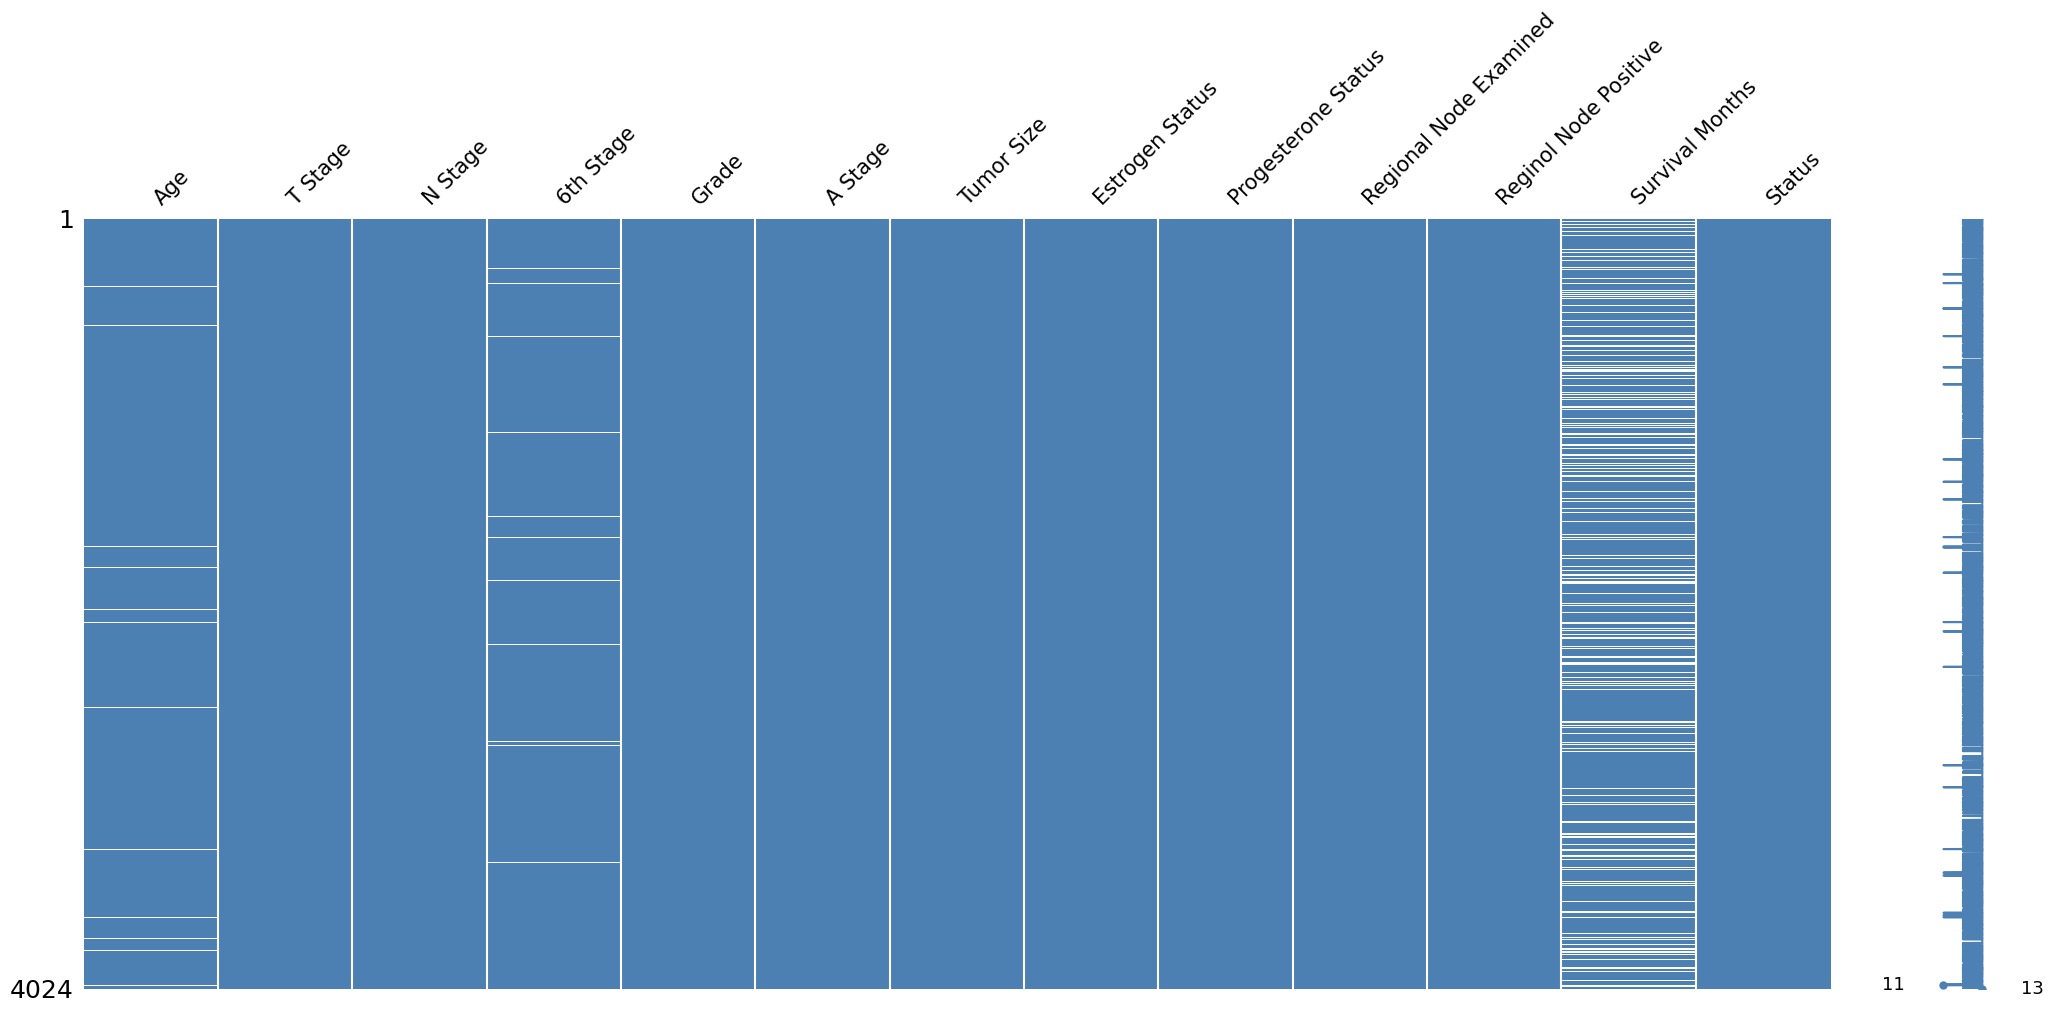

In [10]:
msno.matrix(dataset,color=(0.3, 0.5, 0.7), fontsize=15)

# Now I separate the dataset in training and test datasets

In [11]:
# split the target from the dataset
X = dataset.drop(['Status', 'Survival Months'], axis=1)
y = dataset['Status']  # Target

# splitting dataset in training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

# show dimensions of sets
print(f"Dimensione del training set: {X_train.shape[0]}")
print(f"Dimensione del test set: {X_test.shape[0]}")

Dimensione del training set: 3219
Dimensione del test set: 805


# Declare a transformer

Handle missing values by using different strategies:

-  NUMERICAL FEATURES: I apply a SimpleImputer with the strategy "mean" in order to fill missing values using the column's mean. after imputation i use a StandardScaler, which standardizes the features by transforrming them to have a mean of 0 and a standard deviation of 1. this ensures that all features contribute equally to the analysis. satandardization improve both the stability and the performance of machine learning models.

- CATEGORICAL NOMINAL FEATURES: I use a SimpleImputer with strategy "most frequent" in order to fill missing values presents in the dataset with the most common value in each column. And after imputation i apply OneHotEncoder to convert categorical variables into a numerical format, since many ML algorithms are not able in handling categorical data directly.  

- "AGE": for this column I used a MinMax Scaler, instead of the StandardScaler,
since i want to be sure i will have all positive values.

- CATEGORICAL ORDINAL FEATURES: I apply a SimpleImputer with the "most_frequent" strategy to impute missing values, and the i apply the Ordinal encoder, that assigns to each category in the ordinal feature an integer value based on its order. it preserves the ordinal relationship between cateogires.

In [17]:
# Lists definition of columns to be transformed
columns_to_scale = ['Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']
columns_to_pipe = ['A Stage', 'Estrogen Status', 'Progesterone Status']
columns_to_normalize = ['Age']
ordinalcategorical = ['T Stage', 'N Stage', '6th Stage', 'Grade']
# Tranformation to be applied
# Pipeline for numerical columns
scale_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical columns
pipe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(categories = 'auto', handle_unknown='ignore')) #'auto' = autiomatically determines the cateogries based on the data
])

#use MinMaxScaler on Age since i don't want to have negative values.
normalize_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

#Oridnal encoder for cateogrical ordinal features:
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='error'))
])

# ColumnTransformer
final_transformation = ColumnTransformer(
    transformers=[
        ('numeric', scale_transformer, columns_to_scale),
        ('categorical', pipe_transformer, columns_to_pipe),
        ('Age', normalize_transformer, columns_to_normalize),
        ('ordinal', ordinal_transformer, ordinalcategorical)

    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
    sparse_threshold=0
)

# Model evaluation and selection

Here i define the model. it is composed of a transformer, that i have already defined in the preprocessing step, a sampler: the SMOTE,since i am dealing with unabalced dataset, dimensionality reduction and a classifier.

In [18]:
model_pipeline = IMBPipeline([ #pipeline = an estimator object. it set the steps of the machine leafrning workflow.
    ('trans', final_transformation),
    ('sampler', SMOTE()),
    ('dim_reduction', PCA(n_components=0.8)),
    ('classifier', Perceptron())
])

In [20]:
# to check that the model_pipeline works correctly and that all elements are correctly defined
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('trans',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tumor Size',
                                                   'Regional Node Examined',
                                                   'Reginol Node Positive']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncod...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Age']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['T Stage', 'N Stage',
                                                   '6th Stage', 'Grade'])],
                                   verbose_feature_names_out=False)),
                ('sampler', SMOTE()), ('dim_reduction', PCA(n_components=0.8)),
                ('classifier', Perceptron())])

After having defined all the steps in Pipeline, I define all possible combinations of the models and the hyperparameters I want to use. for each step I have a list containing dictionaries, each corresponding to different models or strategies I can apply for that specific technique in the pipeline.

In [24]:
dim_reduction_configs = [
    {
        'dim_reduction': [None]
    },
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.4, 0.6, 0.9]
    },
    {
        'dim_reduction': [LDA()],
        'dim_reduction__n_components': [1] #= number of axes i want to keep after the transformation.
        #IT MEAns i am projecting my multi-.dimensional array ontyo a one-dimensipnal space, while maximizing class separation.
     },
    {
        'dim_reduction': [SFS(estimator=Perceptron(), forward=False, cv=None, scoring = 'f1')], #MY MODEL USE A DIFFERENT APPROACH FOR EVALUATION. NNOT THE CV.
        'dim_reduction__estimator' : [Perceptron(), LogisticRegression()],
        'dim_reduction__k_features' : [8, 10, 13]
    }
]
classifier_configs = [
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 8]
    },
    {
        'classifier': [Perceptron()],
        'classifier__eta0': loguniform(0.001, 100), #= A PROBABILITY DISTRIBUTION, WHERE THE LOGARITM OF THEN VARIABLE IS UNIFORMLY DISTRIBUTED•
        'classifier__max_iter': [1, 5, 10, 15, 50, 100],#MAXIMUM ITERATION POSSIBLE FOR THE ALGORIOTHM TO CONVERGE.
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier': [LogisticRegression(solver='saga')], #STOCHAST6IC AVERAGER GRAIDENT DESCENT.
        'classifier__C': loguniform(0.001, 100),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier': [DecisionTreeClassifier()],
        'classifier__criterion': ['gini'],
        'classifier__max_depth': [None, 10, 20],
        'classifier__class_weight': [None, 'balanced'] #adjusting the weigh5s of the samples,. balanced = more weight to the minority class.
    },
    {
        'classifier': [SVC()],
        'classifier__C': loguniform(0.001, 100),
        'classifier__kernel': ['linear', 'rbf', 'poly'], #LINEAR KERNEL DOES NOT TRANSDFORM THE DATA, IT JUST USE THE SPACE AS IT IS.
        'classifier__class_weight': [None, 'balanced'] #RBF IT IS CAlled gaussina kernel, it maps the data into a high dimensional space.
    }, #poly maps data into an higher dimensinal space using polynomial functions.
    {
        'classifier': [AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy', max_depth=1))], #decisioon tree is the base esxtimator to be used.
        'classifier__n_estimators': [50,100,200],
        'classifier__learning_rate': [0.01,0.1,0.2]
    },
    {
        'classifier': [RandomForestClassifier()],
        'classifier__n_estimators': [10, 60, 200],
        'classifier__max_features': ['auto', 5, 10, 15, 21]
    }
    ]
sampler_configs = [
    {
        'sampler': [SMOTE()],
        'sampler__sampling_strategy': ['auto', 0.5, 0.75],  # different ways of sampling
        'sampler__k_neighbors': [3, 5]
    }
]

All possible configurations are determined through the cartesian product between the different elements (= dictionaries) in each (of the three) tuple and are represented as tuples made up of 3 dictionaries. Then, in order to pass these tuples to RandomizedSearch CV I need to combine the inner dictionaries into a single one. This merging operation in Phyton is performed by the chain function in the itertools module.

In [25]:
#obtain all possible configurations
all_configs = [dict(itertools.chain(*(e.items()
for e in configuration)))
for configuration in
itertools.product(dim_reduction_configs,classifier_configs,sampler_configs)]

In [26]:
print(f'Number of all possible configurations: {len(all_configs)}')

Number of all possible configurations: 28


In [27]:
all_configs[:2]

[{'dim_reduction': [None],
  'classifier': [KNeighborsClassifier()],
  'classifier__n_neighbors': [3, 5, 8],
  'sampler': [SMOTE()],
  'sampler__sampling_strategy': ['auto', 0.5, 0.75],
  'sampler__k_neighbors': [3, 5]},
 {'dim_reduction': [None],
  'classifier': [Perceptron()],
  'classifier__eta0': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f958638fce0>,
  'classifier__max_iter': [1, 5, 10, 15, 50, 100],
  'classifier__class_weight': [None, 'balanced'],
  'sampler': [SMOTE()],
  'sampler__sampling_strategy': ['auto', 0.5, 0.75],
  'sampler__k_neighbors': [3, 5]}]

At this point I want to use nested cross-validation, a combination of hyperparameter optimization and cross-validation, with the aim to identify 5 different best candidates. The outer loop is implementing a cross validation with 5 folds and for each iteration is run the inner loop, which is again a cross validation with 2 folds that optimizes the model's hyperparameters using RandomizedSearchCV.

In [28]:
#THIS IS THE INNER LOOP
rs = RandomizedSearchCV(model_pipeline,
    param_distributions=all_configs,
    scoring='f1',
    n_iter=len(all_configs) * 4,
    cv=2,
    verbose=1
)
#THIS IS THE OUTER LOOP
scores = cross_validate(rs, X_train, y_train, scoring='f1', cv = 5, return_estimator=True, verbose=3)
#cross validate function returns the best model for each fold iteration, according in this case to f1 measure.
#return_estimator = True to get the best estimator for each fold.

Fitting 2 folds for each of 112 candidates, totalling 224 fits
[CV] END ......................................., score=0.918 total time= 1.6min
Fitting 2 folds for each of 112 candidates, totalling 224 fits
[CV] END ......................................., score=0.906 total time= 1.3min
Fitting 2 folds for each of 112 candidates, totalling 224 fits
[CV] END ......................................., score=0.893 total time= 1.4min
Fitting 2 folds for each of 112 candidates, totalling 224 fits
[CV] END ......................................., score=0.915 total time= 1.1min
Fitting 2 folds for each of 112 candidates, totalling 224 fits
[CV] END ......................................., score=0.900 total time= 1.1min


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  6.6min finished


In [29]:
#print the best 5 models founded by nested cross validation:
for index, estimator in enumerate(scores['estimator']):
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(estimator.best_estimator_.get_params()['sampler'],estimator.best_estimator_.get_params()['sampler'].get_params())
    print(scores['test_score'][index]) # score on validation set, of the best pipeline
    print('-'*10)

SequentialFeatureSelector(cv=None, estimator=LogisticRegression(),
                          forward=False, k_features=(8, 8), scoring='f1')
SVC(C=np.float64(0.0023163647032425965)) {'C': np.float64(0.0023163647032425965), 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
SMOTE(k_neighbors=3, sampling_strategy=0.5) {'k_neighbors': 3, 'random_state': None, 'sampling_strategy': 0.5}
0.9176470588235294
----------
SequentialFeatureSelector(cv=None, estimator=LogisticRegression(),
                          forward=False, k_features=(8, 8), scoring='f1')
AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=1),
                   learning_rate=0.1) {'algorithm': 'deprecated', 'estimator__ccp_alpha

In [30]:
for estimator in scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.9170731707317074, F1 on test set:0.9172831203765972
F1 on training set:0.9097307759985923, F1 on test set:0.912621359223301
F1 on training set:0.8998217468805704, F1 on test set:0.9010043041606887
F1 on training set:0.907358390682901, F1 on test set:0.911660777385159
F1 on training set:0.9030758226037195, F1 on test set:0.9028571428571428


Based on the F1 scores on the test set, the first model appears to be the best model since it has the highest F1 score on the test set, which indicates that it performs best in terms of balancing precision and recall on unseen data.


# Hyperparameter tuning

 I re-run an hyperparameters optimization on the selected best model, fixing the modeling approach and varying the hyperparameters in a range close to the selected model's one

In [31]:
#this is the pipeline of the selected model:
best_model_pipeline = IMBPipeline([
    ('trans', final_transformation),
    ('sampler', SMOTE(sampling_strategy=0.75)),
    ('dim_reduction', LDA(n_components=1) ),
    ('classifier', SVC(C=4.554569780848221, kernel='poly'))
])

For SVC classifier I decided to tune these parameters:
*   Classifier C: the best model has C = 0.0023,
*   Classifier kernel: the best model has kernel =  "rbf".

In [32]:
params= {
    'classifier__C': [4.500, 4.525, 4.555, 4.565],
    'classifier__kernel': ['linear', 'rbf', 'poly']
}

In [33]:
#GridSearch CV to identify the best configuraiton
gs_best = GridSearchCV(best_model_pipeline, param_grid=params, scoring='f1', cv=5, verbose=3)
gs_best.fit(X_train, y_train)
#5 folds and for each 9 candidates, so total = 45 fits

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END classifier__C=4.5, classifier__kernel=linear;, score=0.850 total time=   0.7s
[CV 2/5] END classifier__C=4.5, classifier__kernel=linear;, score=0.879 total time=   0.7s
[CV 3/5] END classifier__C=4.5, classifier__kernel=linear;, score=0.845 total time=   0.8s
[CV 4/5] END classifier__C=4.5, classifier__kernel=linear;, score=0.877 total time=   0.7s
[CV 5/5] END classifier__C=4.5, classifier__kernel=linear;, score=0.865 total time=   0.9s
[CV 1/5] END classifier__C=4.5, classifier__kernel=rbf;, score=0.850 total time=   1.8s
[CV 2/5] END classifier__C=4.5, classifier__kernel=rbf;, score=0.871 total time=   1.8s
[CV 3/5] END classifier__C=4.5, classifier__kernel=rbf;, score=0.835 total time=   2.6s
[CV 4/5] END classifier__C=4.5, classifier__kernel=rbf;, score=0.854 total time=   2.1s
[CV 5/5] END classifier__C=4.5, classifier__kernel=rbf;, score=0.833 total time=   2.8s
[CV 1/5] END classifier__C=4.5, classifier__

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('trans',
                                        ColumnTransformer(remainder='passthrough',
                                                          sparse_threshold=0,
                                                          transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Tumor '
                                                                          'Size',
                                                                          'Regional '
                                                                          'Node '
                                                                          'Examined',
                                                                          'Reginol '
                                                                          'Node '
                                                                          'Positive']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='m...
                                                                          'Stage',
                                                                          'N '
                                                                          'Stage',
                                                                          '6th '
                                                                          'Stage',
                                                                          'Grade'])],
                                                          verbose_feature_names_out=False)),
                                       ('sampler',
                                        SMOTE(sampling_strategy=0.75)),
                                       ('dim_reduction',
                                        LinearDiscriminantAnalysis(n_components=1)),
                                       ('classifier',
                                        SVC(C=4.554569780848221,
                                            kernel='poly'))]),
             param_grid={'classifier__C': [4.5, 4.525, 4.555, 4.565],
                         'classifier__kernel': ['linear', 'rbf', 'poly']},
             scoring='f1', verbose=3)

In [34]:
cls = gs_best.best_estimator_
print(cls)

Pipeline(steps=[('trans',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tumor Size',
                                                   'Regional Node Examined',
                                                   'Reginol Node Positive']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                 

In [44]:
predictions = cls.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, predictions):.4f}')
print(f'F1 (macro): {f1_score(y_test, predictions, average="macro"):.4f}')
print(f'F1 (Alive only): {f1_score(y_test, predictions):.4f}')
print()
print(classification_report(y_test, predictions, target_names=['Dead', 'Alive']))

Accuracy: 0.8509
F1 (macro): 0.5836
F1 (Alive only): 0.9172

              precision    recall  f1-score   support

        Dead       0.54      0.16      0.25       123
       Alive       0.87      0.98      0.92       682

    accuracy                           0.85       805
   macro avg       0.70      0.57      0.58       805
weighted avg       0.82      0.85      0.82       805



The F1 reported above is computed on the majority class (Alive), which accounts for 84.7% of the dataset. Taken alone it is misleading: a classifier that always predicts "Alive" reaches F1 = 0.9173 on the same test set, which is higher than the 0.9029 obtained here.

The per-class report makes the difference visible. On the 123 deceased patients in the test set the model reaches precision 0.43 and recall 0.30, identifying 37 of them. Macro F1 is 0.63.

Once Survival Months is excluded, the remaining clinical variables — stage, tumour size, node counts, receptor status and age — do not separate the two classes in this formulation. The apparent performance of the earlier version came from that feature.

In [36]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report

# baseline: predice sempre la classe maggioritaria
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print("Baseline (always majority class)")
print(f"  F1 on test set: {f1_score(y_test, dummy.predict(X_test)):.4f}")

print("\nModel")
print(f"  F1 on test set: {f1_score(y_test, pred_test):.4f}")
print(classification_report(y_test, pred_test, target_names=['Dead','Alive']))

Baseline (always majority class)
  F1 on test set: 0.9173

Model
  F1 on test set: 0.9029
              precision    recall  f1-score   support

        Dead       0.43      0.30      0.35       123
       Alive       0.88      0.93      0.90       682

    accuracy                           0.83       805
   macro avg       0.65      0.61      0.63       805
weighted avg       0.81      0.83      0.82       805



## Learning Curve

The learning curve shows how a machine learning model's performance improves as it is trained on more data. it highlights the relationship between the model's performance and the size of the training data. it is useful in checking whether I am in a underfitting, or overfitting or in a good fit situation.

In [37]:
train_sizes, train_scores, test_scores = learning_curve(cls,
                                                       X=X_train,
                                                       y=y_train,
                                                       train_sizes= [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                       cv = 5,
                                                       n_jobs = -1,
                                                       scoring = 'f1',
                                                       shuffle = False)

(0.8, 1.03)

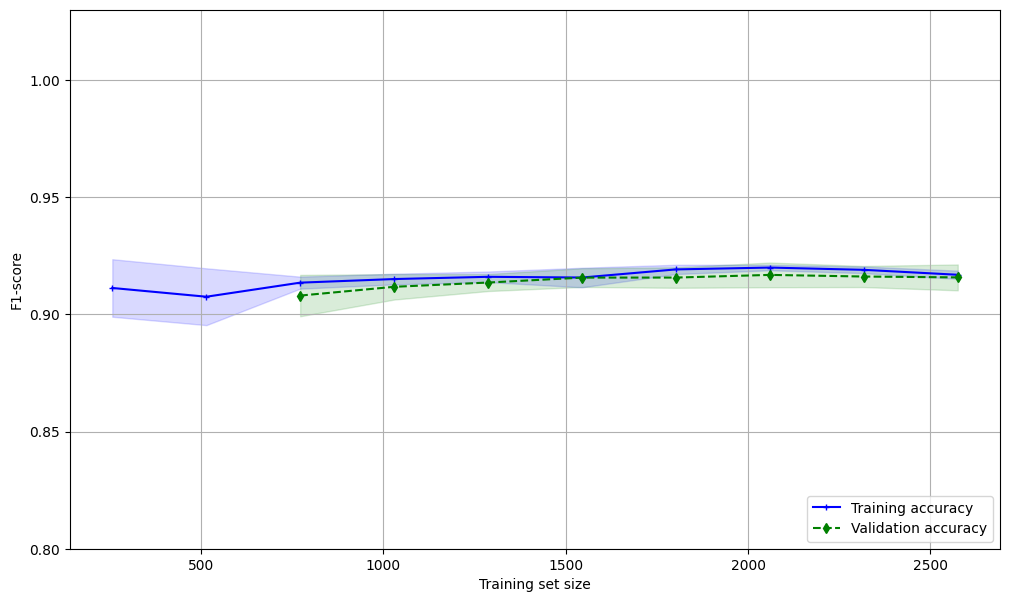

In [38]:

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
        color='blue', marker='+',
        markersize=5, label='Training accuracy')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=5,
         label='Validation accuracy')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.80, 1.03])

As the training set size increases, both the training and the validation accuracy curves rise and tend to converge. this behaviour suggests that the model is imporving as it learns form more data. since the lines converge the model is not showing overfitting, since validation and training performances are similar. Both curves show fluctuations before stabilizing, but in the end they reach a quite high value associated to the performance measure f1.
i see also tha tthe shaded area, which represents the uncertainty in accuracy measurements, is larger at the beginning, when the training set is small and then shows a decreasing behaviour. this indicates that with more data the model's performance becomes more reliable and less affected by variations in the training data.

## AUC-ROC Curve

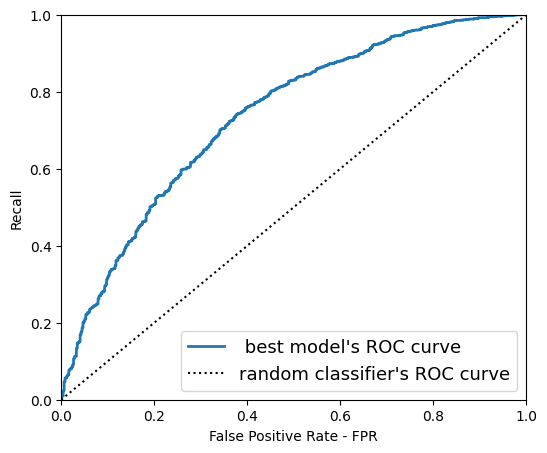

In [40]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot()
ax.plot(fprs, recalls, linewidth=2, label=" best model's ROC curve")
ax.plot([0, 1], [0, 1], 'k:', label= "random classifier's ROC curve")
ax.set_xlabel('False Positive Rate - FPR')
ax.set_ylabel('Recall')
ax.axis([0, 1, 0, 1])
ax.legend(loc="lower right", fontsize=13)

As the training set size increases, both the training and the validation curves rise and converge, and the shaded band representing uncertainty narrows — with more data the estimate becomes more stable and less sensitive to how the training set is drawn.

Convergence alone, however, is not evidence of a good fit. Both curves settle close to the F1 a majority-class classifier would obtain on this data, and the gap between training and validation performance is almost zero (0.9171 against 0.9173 in the first fold). A model that has fitted a decision boundary normally scores higher on the data it was trained on; here it does not, because no boundary has been fitted. The model is defaulting to the majority label regardless of the input.

So the curves are not showing underfitting in the usual sense of a model too simple for the data. They are showing that the features carry too little signal for the model to do better than predicting "Alive" for everyone.

### Confusion matrix on the Test set

array([[ 20, 103],
       [ 17, 665]])

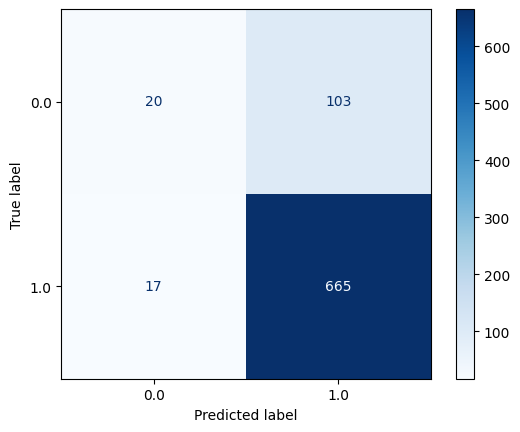

In [41]:
y_test_predicted = cls.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_test_predicted)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_predicted, cmap=plt.cm.Blues)
plt.show
conf_matrix

Finally, the confusion matrix shows that the best selected model is very able in correctly classify positive samples (648), missing only few (15) False Negative samples. Anyway i see that the model can be improved in reducing the number of False Positives (72), that is significantly higher than the number of true negatives. this confirm the reult obtained before in the measurements with recall and precision, where the first one was greater than the second for my model.

**PRECISION RECALL CURVE**

In [42]:
scores = cls.decision_function(X_test)
precisions, recalls, thresholds = precision_recall_curve(y_test, scores)

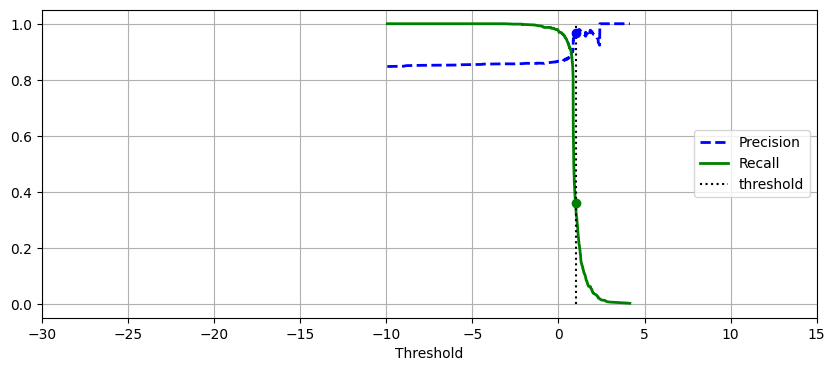

In [43]:
threshold = 1
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot()
ax.plot(thresholds, precisions[:-1], "b--", label="Precision", lw=2)
ax.plot(thresholds, recalls[:-1], "g-", label="Recall", lw=2)
ax.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.grid()
ax.set_xlabel("Threshold")
ax.set_xlim((-30,15))
plt.legend(loc="center right")
plt.show()

This final plot demonstrates that achieving high scores in both recall and precision requires a trade-off. if i want to optimize the precision the model will decrease strongly in recalling. The good balance between precision and recall is constrained by the use of f1 as performance metrics of my classifier.

**CONCLUSION**

The pipeline behaves as intended: imputation, scaling and resampling are fitted inside each fold, model selection uses nested cross-validation over 112 configurations, and evaluation includes learning and validation curves, ROC and precision–recall analysis.

The result is negative. With Survival Months excluded, the model does not outperform a majority-class baseline (F1 0.9029 against 0.9173) and recovers 30% of the deceased patients. The clinical variables available here are not sufficient for this classification task as framed.

A better formulation would predict mortality at a fixed horizon — 36 or 60 months — excluding patients censored before it, which is how the survival literature handles this data.